# TF Motif Enrichment Analysis — All Cell Types
Motif Enrichment 결과를 cell type 간 비교 시각화

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

base = '/data1/project/yeonu/065_multi_atac/TFmotif/results_output/'

cell_types = {
    'Hepatocyte': 'Hepatocyte_Motif_Enrichment.csv',
    'T_Cells': 'T_Cells_Motif_Enrichment.csv',
    'Mesenchymal': 'Mesenchymal_Motif_Enrichment.csv',
    'Macrophages': 'Macrophages_Motif_Enrichment.csv',
    'NK_Cells': 'NK_Cells_Motif_Enrichment.csv',
    'DCs': 'DCs_Motif_Enrichment.csv',
}

enrich = {}
for ct, fname in cell_types.items():
    df = pd.read_csv(base + fname, index_col=0)
    df['cell_type'] = ct
    enrich[ct] = df
    n_sig = (df['p.adjust'] < 0.05).sum()
    print(f'{ct:15s}: {len(df)} motifs tested, {n_sig} significant (FDR < 0.05)')

# Hepatocyte 기준 데이터
hep = enrich['Hepatocyte']
hep.head()

Hepatocyte     : 692 motifs tested, 291 significant (FDR < 0.05)
T_Cells        : 692 motifs tested, 203 significant (FDR < 0.05)
Mesenchymal    : 692 motifs tested, 167 significant (FDR < 0.05)
Macrophages    : 692 motifs tested, 35 significant (FDR < 0.05)
NK_Cells       : 692 motifs tested, 0 significant (FDR < 0.05)
DCs            : 692 motifs tested, 0 significant (FDR < 0.05)


,motif,observed,background,percent.observed,percent.background,fold.enrichment,pvalue,motif.name,p.adjust,cell_type
MA1513.1,MA1513.1,393,9891,57.205240,24.7275,2.313426,1.195073e-74,KLF15,8.269903e-72,Hepatocyte
MA0516.3,MA0516.3,394,10061,57.350801,25.1525,2.280123,5.090266e-73,SP2,1.761232e-70,Hepatocyte
MA1959.1,MA1959.1,371,9294,54.002911,23.2350,2.324205,4.227898e-69,KLF7,9.752352e-67,Hepatocyte
MA0742.2,MA0742.2,374,9519,54.439592,23.7975,2.287618,5.898626e-68,KLF12,1.020462e-65,Hepatocyte
MA0079.5,MA0079.5,389,10360,56.622999,25.9000,2.186216,3.147813e-66,SP1,4.356573e-64,Hepatocyte


## 1. Hepatocyte — Top 30 Enriched Motifs (Bar Plot)

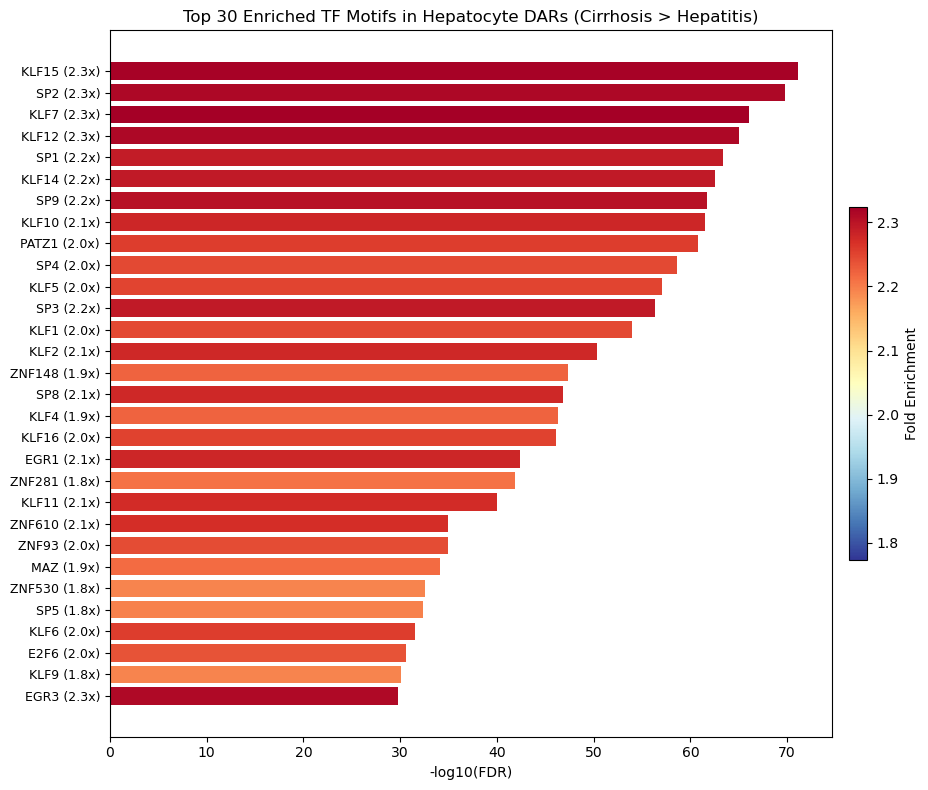

In [2]:
top30 = hep.head(30).copy()
top30['-log10_padj'] = -np.log10(top30['p.adjust'].clip(lower=1e-300))

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.RdYlBu_r(top30['fold.enrichment'] / top30['fold.enrichment'].max())
ax.barh(range(len(top30)), top30['-log10_padj'], color=colors)
ax.set_yticks(range(len(top30)))
ax.set_yticklabels([f"{row['motif.name']} ({row['fold.enrichment']:.1f}x)" 
                     for _, row in top30.iterrows()], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('-log10(FDR)')
ax.set_title('Top 30 Enriched TF Motifs in Hepatocyte DARs (Cirrhosis > Hepatitis)')

# fold enrichment colorbar
sm = plt.cm.ScalarMappable(cmap='RdYlBu_r', 
     norm=plt.Normalize(top30['fold.enrichment'].min(), top30['fold.enrichment'].max()))
cbar = plt.colorbar(sm, ax=ax, shrink=0.5, pad=0.02)
cbar.set_label('Fold Enrichment')

plt.tight_layout()
plt.show()

## 2. Motif Enrichment Heatmap — Cell Type 간 비교

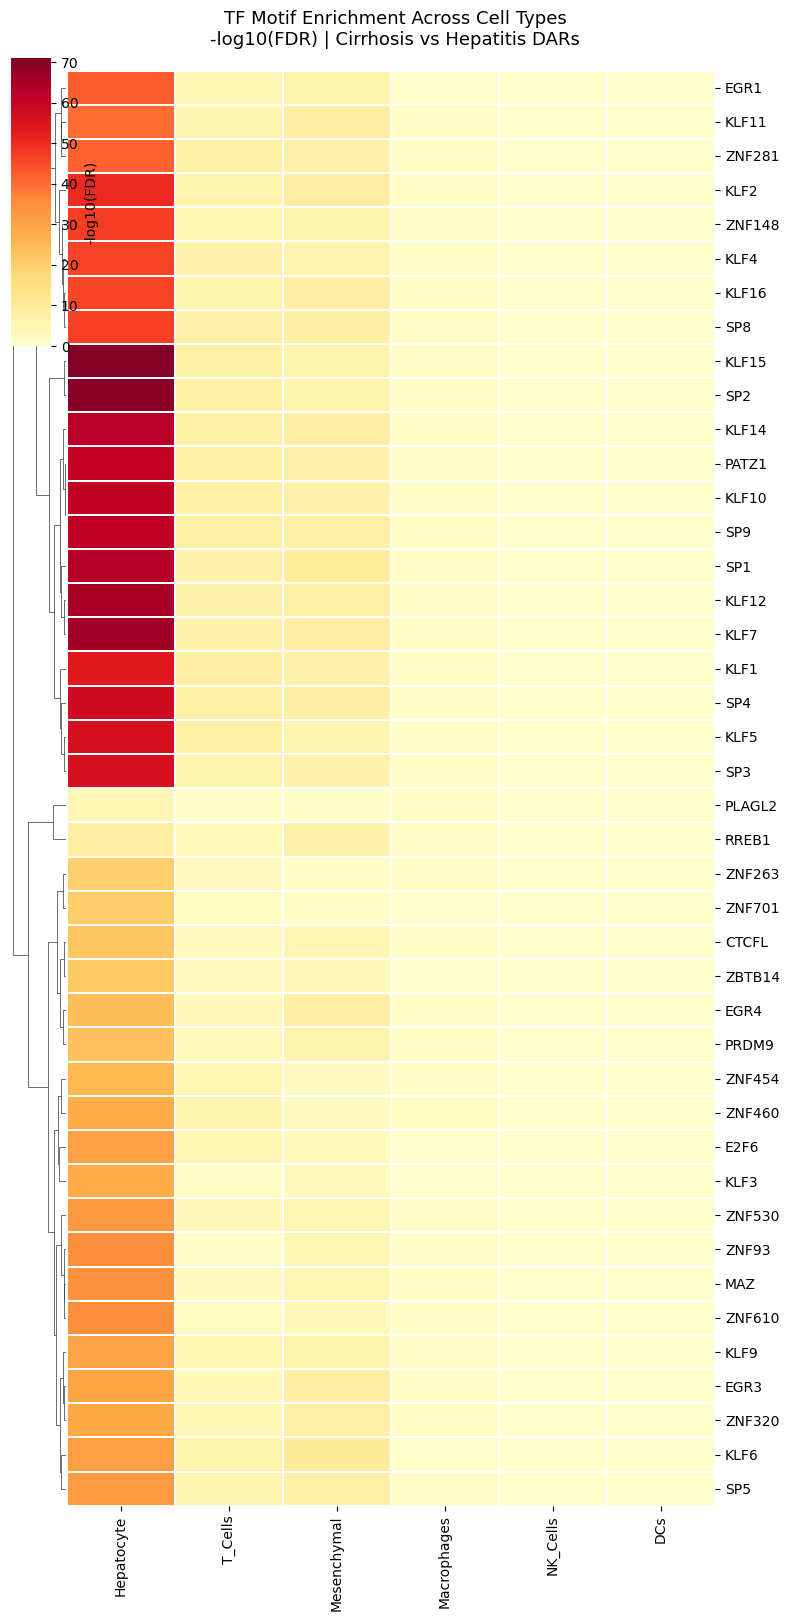

Total motifs shown: 42


In [3]:
# 각 cell type에서 유의한 motif의 합집합 중 상위 선택
# Hepatocyte 상위 40 + 각 cell type 상위 10의 합집합
top_motifs = set(hep.head(40)['motif.name'])
for ct, df in enrich.items():
    sig = df[df['p.adjust'] < 0.05]
    top_motifs.update(sig.head(10)['motif.name'])

# -log10(FDR) matrix 생성
ct_order = ['Hepatocyte', 'T_Cells', 'Mesenchymal', 'Macrophages', 'NK_Cells', 'DCs']
motif_list = sorted(top_motifs)

mat = pd.DataFrame(index=motif_list, columns=ct_order, dtype=float)
for ct in ct_order:
    df = enrich[ct].set_index('motif.name')
    for m in motif_list:
        if m in df.index:
            row = df.loc[m]
            if isinstance(row, pd.DataFrame):
                row = row.iloc[0]
            mat.loc[m, ct] = -np.log10(max(row['p.adjust'], 1e-300))
        else:
            mat.loc[m, ct] = 0

mat = mat.astype(float)

# significance threshold line 값
sig_line = -np.log10(0.05)  # ~1.3

g = sns.clustermap(
    mat, cmap='YlOrRd', vmin=0, vmax=mat.values.max(),
    row_cluster=True, col_cluster=False,
    yticklabels=True, xticklabels=True,
    figsize=(8, 16),
    cbar_kws={'label': '-log10(FDR)', 'shrink': 0.5},
    dendrogram_ratio=(0.08, 0.02),
    linewidths=0.3, linecolor='white'
)
g.ax_heatmap.set_xlabel('')
g.ax_heatmap.set_ylabel('')
g.fig.suptitle('TF Motif Enrichment Across Cell Types\n-log10(FDR) | Cirrhosis vs Hepatitis DARs', 
               y=1.01, fontsize=13)
plt.show()
print(f'Total motifs shown: {len(motif_list)}')

## 3. Fold Enrichment Heatmap — Cell Type 간 비교

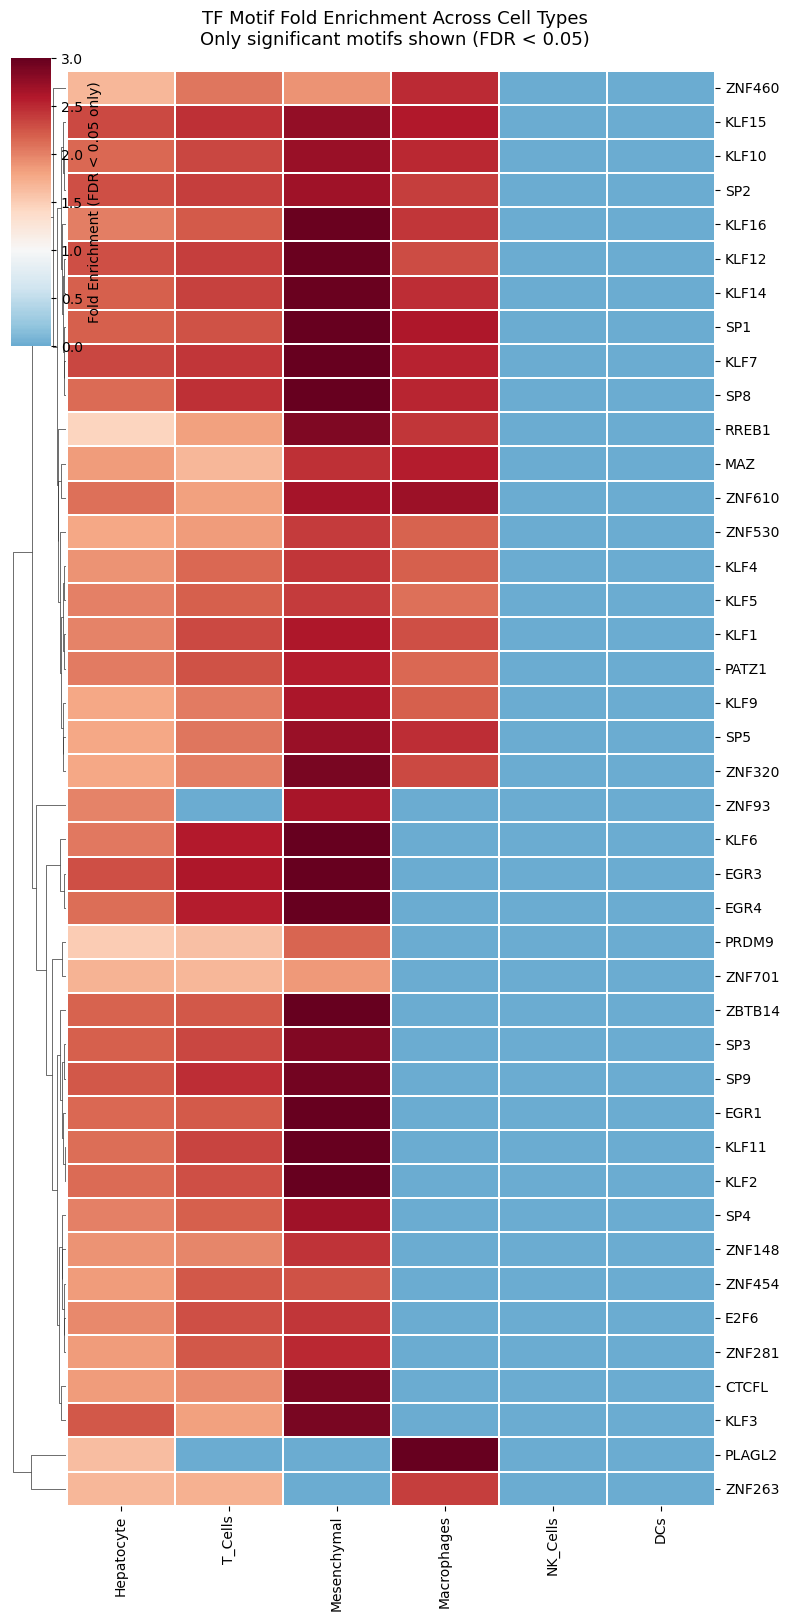

In [4]:
# Fold enrichment matrix
mat_fe = pd.DataFrame(index=motif_list, columns=ct_order, dtype=float)
for ct in ct_order:
    df = enrich[ct].set_index('motif.name')
    for m in motif_list:
        if m in df.index:
            row = df.loc[m]
            if isinstance(row, pd.DataFrame):
                row = row.iloc[0]
            # 유의하지 않으면 0 처리
            if row['p.adjust'] < 0.05:
                mat_fe.loc[m, ct] = row['fold.enrichment']
            else:
                mat_fe.loc[m, ct] = 0
        else:
            mat_fe.loc[m, ct] = 0

mat_fe = mat_fe.astype(float)

g = sns.clustermap(
    mat_fe, cmap='RdBu_r', center=1, vmin=0, vmax=3,
    row_cluster=True, col_cluster=False,
    yticklabels=True, xticklabels=True,
    figsize=(8, 16),
    cbar_kws={'label': 'Fold Enrichment (FDR < 0.05 only)', 'shrink': 0.5},
    dendrogram_ratio=(0.08, 0.02),
    linewidths=0.3, linecolor='white'
)
g.ax_heatmap.set_xlabel('')
g.ax_heatmap.set_ylabel('')
g.fig.suptitle('TF Motif Fold Enrichment Across Cell Types\nOnly significant motifs shown (FDR < 0.05)', 
               y=1.01, fontsize=13)
plt.show()

## 4. Hepatocyte-Specific Motifs — 다른 cell type에서는 유의하지 않은 motif

In [5]:
# Hepatocyte에서 유의하고 나머지 cell type에서는 유의하지 않은 motif
hep_sig = set(hep[hep['p.adjust'] < 0.05]['motif.name'])
other_sig = set()
for ct in ['T_Cells', 'Mesenchymal', 'Macrophages', 'NK_Cells', 'DCs']:
    other_sig.update(enrich[ct][enrich[ct]['p.adjust'] < 0.05]['motif.name'])

hep_only = hep_sig - other_sig
shared = hep_sig & other_sig

print(f'Hepatocyte significant motifs: {len(hep_sig)}')
print(f'Shared with other cell types:  {len(shared)}')
print(f'Hepatocyte-specific:           {len(hep_only)}')

# Hepatocyte-specific motifs 상세
hep_spec_df = hep[hep['motif.name'].isin(hep_only)].sort_values('p.adjust')
print(f'\nTop 20 Hepatocyte-specific motifs:')
hep_spec_df[['motif.name', 'fold.enrichment', 'percent.observed', 'percent.background', 'p.adjust']].head(20)

Hepatocyte significant motifs: 291
Shared with other cell types:  175
Hepatocyte-specific:           116

Top 20 Hepatocyte-specific motifs:


,motif.name,fold.enrichment,percent.observed,percent.background,p.adjust
MA0131.2,HINFP,2.297378,13.973799,6.0825,3.382713e-13
MA1122.1,TFDP1,1.910779,20.378457,10.6650,4.578907e-13
MA1966.1,TFAP4::ETV1,1.707552,22.270742,13.0425,1.639913e-10
MA0696.1,ZIC1,1.885453,15.866084,8.4150,1.119448e-09
MA0769.2,TCF7,2.013129,13.100437,6.5075,2.330702e-09
MA0014.3,PAX5,2.328967,9.170306,3.9375,6.515479e-09
MA1930.1,CTCF.2,1.479722,29.694323,20.0675,8.795441e-09
MA0502.2,NFYB,1.853000,14.847162,8.0125,1.075492e-08
MA1574.1,THRB,1.749224,16.302766,9.3200,3.599341e-08
MA0695.1,ZBTB7C,1.948825,11.790393,6.0500,7.365114e-08


## 5. Upset-style Summary — 각 Cell Type별 Significant Motif 수

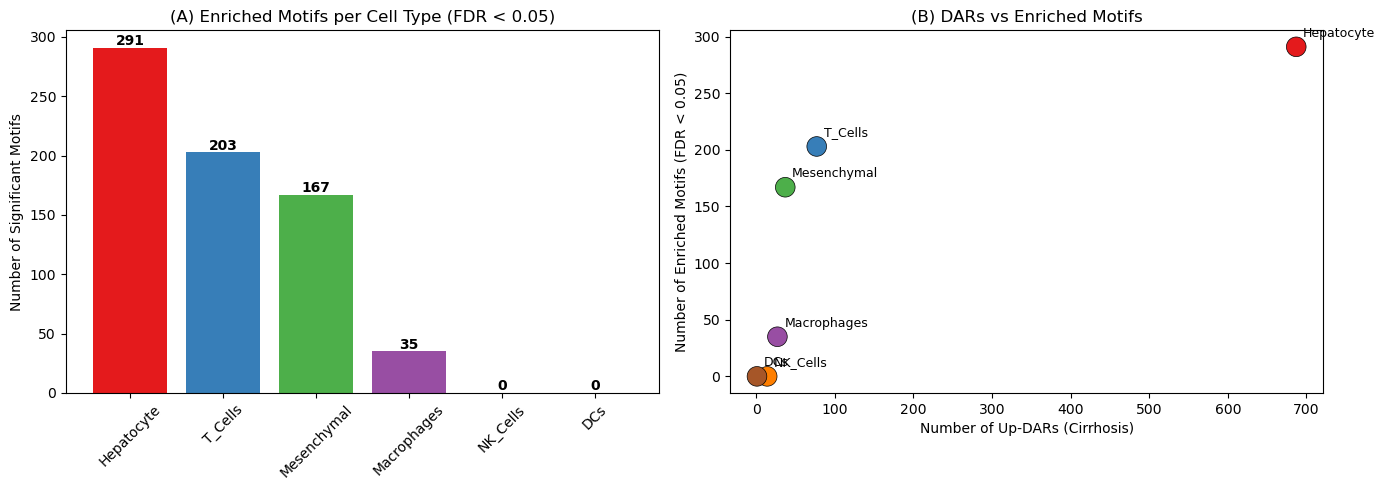

In [6]:
# 각 cell type별 significant motif 수 비교
sig_counts = {}
for ct in ct_order:
    sig_counts[ct] = (enrich[ct]['p.adjust'] < 0.05).sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (A) Significant motif count per cell type
colors_ct = {'Hepatocyte': '#e41a1c', 'T_Cells': '#377eb8', 'Mesenchymal': '#4daf4a',
             'Macrophages': '#984ea3', 'NK_Cells': '#ff7f00', 'DCs': '#a65628'}
bars = axes[0].bar(sig_counts.keys(), sig_counts.values(),
                   color=[colors_ct[ct] for ct in sig_counts.keys()])
axes[0].set_ylabel('Number of Significant Motifs')
axes[0].set_title('(A) Enriched Motifs per Cell Type (FDR < 0.05)')
axes[0].tick_params(axis='x', rotation=45)
for bar, v in zip(bars, sig_counts.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 2, str(v),
                 ha='center', fontsize=10, fontweight='bold')

# (B) DAR 수 대비 enriched motif 비율
dar_counts = {'Hepatocyte': 687, 'T_Cells': 77, 'Mesenchymal': 37,
              'Macrophages': 27, 'NK_Cells': 14, 'DCs': 1}
axes[1].scatter([dar_counts[ct] for ct in ct_order],
               [sig_counts[ct] for ct in ct_order],
               s=200, c=[colors_ct[ct] for ct in ct_order],
               edgecolors='k', linewidths=0.5, zorder=3)
for ct in ct_order:
    axes[1].annotate(ct, (dar_counts[ct], sig_counts[ct]),
                     fontsize=9, ha='left', va='bottom',
                     xytext=(5, 5), textcoords='offset points')
axes[1].set_xlabel('Number of Up-DARs (Cirrhosis)')
axes[1].set_ylabel('Number of Enriched Motifs (FDR < 0.05)')
axes[1].set_title('(B) DARs vs Enriched Motifs')

plt.tight_layout()
plt.show()

## 6. Motif Enrichment Dot Plot — Top Motifs × Cell Types

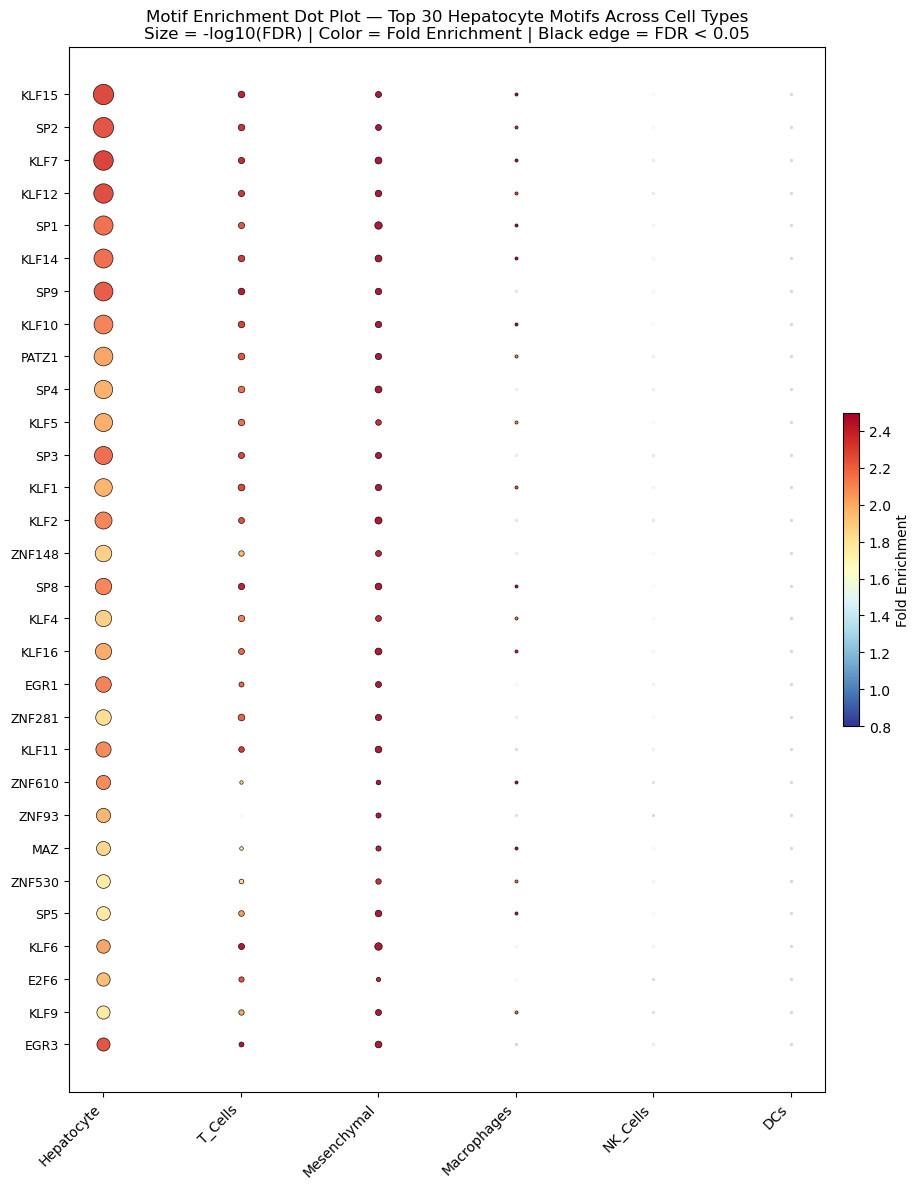

In [7]:
# Hepatocyte 상위 30 motif에 대해 dot plot
top30_names = hep.head(30)['motif.name'].tolist()

rows = []
for ct in ct_order:
    df = enrich[ct].set_index('motif.name')
    for m in top30_names:
        if m in df.index:
            row = df.loc[m]
            if isinstance(row, pd.DataFrame):
                row = row.iloc[0]
            rows.append({
                'motif': m, 'cell_type': ct,
                'fold_enrichment': row['fold.enrichment'],
                '-log10_padj': -np.log10(max(row['p.adjust'], 1e-300)),
                'significant': row['p.adjust'] < 0.05
            })
        else:
            rows.append({'motif': m, 'cell_type': ct,
                         'fold_enrichment': 1, '-log10_padj': 0, 'significant': False})

dot_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 12))

for _, row in dot_df.iterrows():
    x = ct_order.index(row['cell_type'])
    y = top30_names.index(row['motif'])
    size = row['-log10_padj'] * 3
    color = row['fold_enrichment']
    edge = 'black' if row['significant'] else 'lightgrey'
    alpha = 0.9 if row['significant'] else 0.2
    ax.scatter(x, y, s=max(size, 5), c=[color], cmap='RdYlBu_r',
              vmin=0.8, vmax=2.5, edgecolors=edge, linewidths=0.5, alpha=alpha)

ax.set_xticks(range(len(ct_order)))
ax.set_xticklabels(ct_order, rotation=45, ha='right')
ax.set_yticks(range(len(top30_names)))
ax.set_yticklabels(top30_names, fontsize=9)
ax.invert_yaxis()
ax.set_title('Motif Enrichment Dot Plot — Top 30 Hepatocyte Motifs Across Cell Types\n'
             'Size = -log10(FDR) | Color = Fold Enrichment | Black edge = FDR < 0.05')

# colorbar
sm = plt.cm.ScalarMappable(cmap='RdYlBu_r', norm=plt.Normalize(0.8, 2.5))
cbar = plt.colorbar(sm, ax=ax, shrink=0.3, pad=0.02)
cbar.set_label('Fold Enrichment')

plt.tight_layout()
plt.show()